# Advance model
## 1. Define the Data Generators

In [1]:
import os
from keras.utils import image_dataset_from_directory

batch_size = 36
image_size = (224, 224)

base_dir = '.'
data_dir = os.path.join(base_dir, "dataset", "signlang_v2")

#base paths from the datasets
train_dir = os.path.join(data_dir, "train")
val_dir   = os.path.join(data_dir, "val")
test_dir  = os.path.join(data_dir, "test")

#creating the datasets
train_dataset = image_dataset_from_directory(
    train_dir,
    image_size=image_size,
    batch_size=batch_size,
    label_mode="categorical", #categorical because we're dealing with many classes
    shuffle=True
)

validation_dataset = image_dataset_from_directory(
    val_dir,
    image_size=image_size,
    batch_size=batch_size,
    label_mode="categorical",
    shuffle=False
)

test_dataset = image_dataset_from_directory(
    test_dir,
    image_size=image_size,
    batch_size=batch_size,
    label_mode="categorical",
    shuffle=False
)

epochs = 26

C:\Users\user\AppData\Local\Programs\Python\Python312\Lib\site-packages\keras\src\export\tf2onnx_lib.py:8: FutureWarning: In the future `np.object` will be defined as the corresponding NumPy scalar.
  if not hasattr(np, "object"):


Found 1702 files belonging to 10 classes.
Found 548 files belonging to 10 classes.
Found 287 files belonging to 10 classes.



## 2. Test the generators

In [2]:
for data_batch, label_batch in train_dataset:
    print('data batch shape ', data_batch.shape)
    print('label batch shape ', label_batch.shape)
    print('sample data shape ', data_batch[0].shape)
    print('sample labels ', label_batch[:5].numpy()) #show the first 5 labels

    break

data batch shape  (36, 224, 224, 3)
label batch shape  (36, 10)
sample data shape  (224, 224, 3)
sample labels  [[0. 0. 0. 0. 0. 0. 0. 0. 1. 0.]
 [0. 0. 0. 0. 0. 0. 1. 0. 0. 0.]
 [1. 0. 0. 0. 0. 0. 0. 0. 0. 0.]
 [1. 0. 0. 0. 0. 0. 0. 0. 0. 0.]
 [0. 0. 0. 0. 0. 0. 0. 1. 0. 0.]]



## 3. Images from the dataset

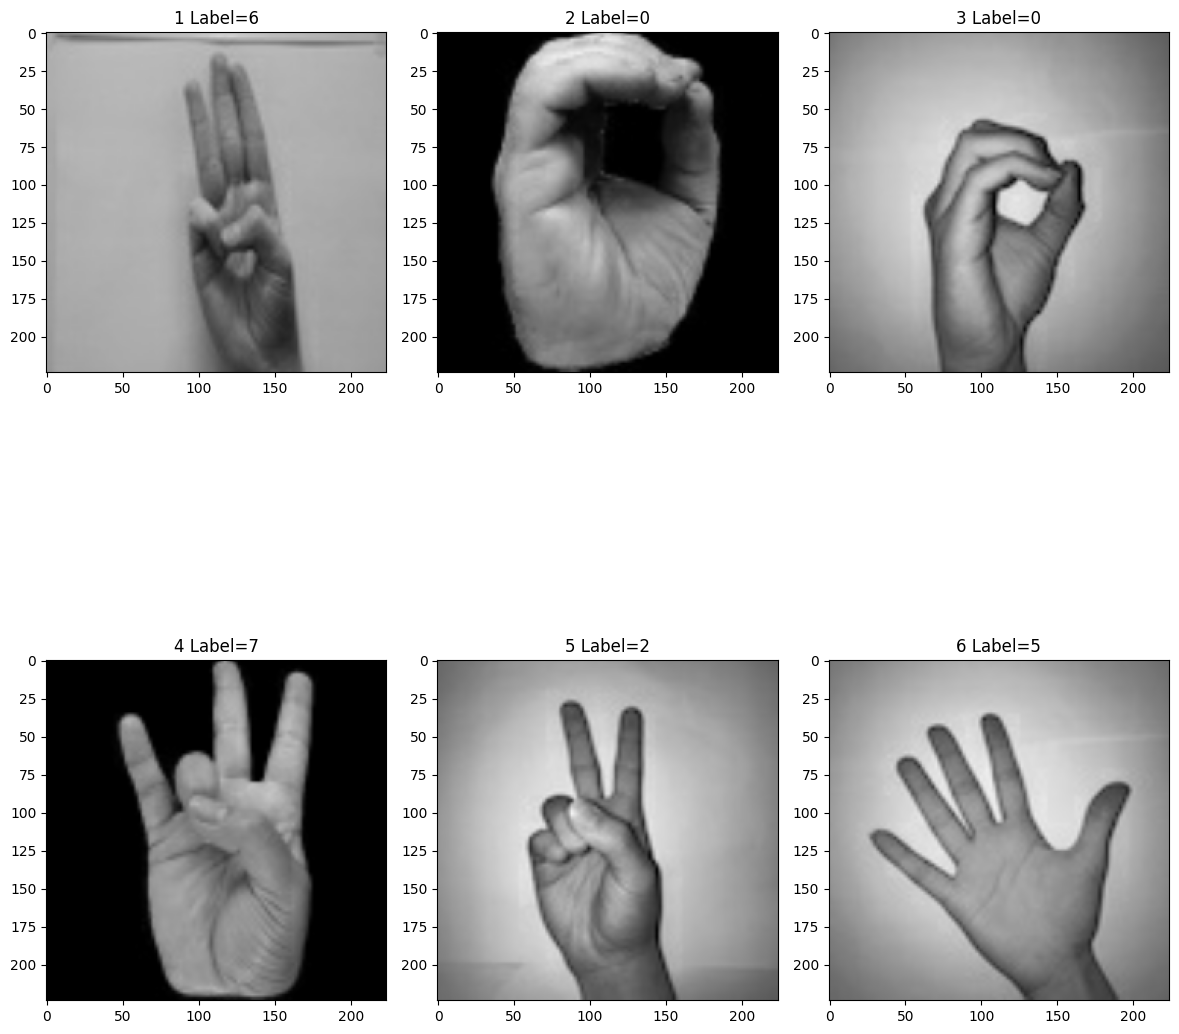

In [3]:
import matplotlib.pyplot as plt
import numpy as np

fig=plt.figure(figsize=(12,15))
columns = 3
rows = 2

for i in range(1, 7):
    img = data_batch[i]/255
    ax =fig.add_subplot(rows, columns, i)

    lbl = str(np.argmax(label_batch[i]))

    fig.tight_layout()
    ax.title.set_text(str(i)+ " Label=" + lbl)
    plt.imshow(img)
plt.show()


## 4.  Define the network with VGG16 and techniques

In [4]:
import keras
from keras import models, layers, regularizers
from keras.applications import VGG16

vgg_base = VGG16(weights='imagenet', include_top=False,input_shape=(224,224,3)) #(150,150,3)
vgg_base.trainable = False

network = models.Sequential()
network.add(layers.Input(shape=(224,224,3)))

#network.add(layers.RandomFlip("horizontal")
network.add(layers.RandomRotation(0.05))
network.add(layers.RandomZoom(0.05))
#network.add(layers.RandomContrast(0.2))

network.add(layers.Rescaling(1./255))

network.add(vgg_base)
network.add(layers.GlobalAveragePooling2D())

network.add(layers.Dense(512, activation='relu', kernel_regularizer=regularizers.l2(0.005)))
network.add(layers.Dropout(0.2))

network.add(layers.Dense(256, activation='relu', kernel_regularizer=regularizers.l2(0.0001)))
network.add(layers.Dropout(0.2))

network.add(layers.Dense(10, activation='softmax'))

network.summary()


Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ random_rotation                 │ (None, 224, 224, 3)    │             0 │
│ (RandomRotation)                │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ random_zoom (RandomZoom)        │ (None, 224, 224, 3)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ rescaling (Rescaling)           │ (None, 224, 224, 3)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ vgg16 (Functional)              │ (None, 7, 7, 512)      │    14,714,688 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ global_average_pooling2d        │ (None, 512)            │             0 │
│ (GlobalAveragePooling2D)        │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 512)            │       262,656 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 512)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 256)            │       131,328 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_1 (Dropout)             │ (None, 256)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_2 (Dense)                 │ (None, 10)             │         2,570 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 15,111,242 (57.64 MB)

 Trainable params: 396,554 (1.51 MB)

 Non-trainable params: 14,714,688 (56.13 MB)


## 5. Compile and Train

In [ ]:
#from tensorflow.keras import optimizers
from keras import callbacks

#callbacks help to save intermediate results.

callbacks_vgg = [callbacks.ModelCheckpoint(
                filepath = "convnet_base_vgg.keras",
                save_best_only=True,
                monitor="val_loss"),

                callbacks.EarlyStopping(
                monitor="val_loss",
                patience=6,
                restore_best_weights=True),
            ]

# network.compile(loss='binary_crossentropy', optimizer=optimizers.RMSprop(learning_rate=1e-4), metrics=['acc']) # alternative showing use of learning rate
network.compile(loss='categorical_crossentropy', optimizer="adam", metrics=['acc'])

history_vgg = network.fit(train_dataset, epochs=epochs, validation_data=validation_dataset,callbacks=callbacks_vgg)


Epoch 1/26
48/48 ━━━━━━━━━━━━━━━━━━━━ 160s 3s/step - acc: 0.1986 - loss: 3.5345 - val_acc: 0.3777 - val_loss: 2.6051
Epoch 2/26
48/48 ━━━━━━━━━━━━━━━━━━━━ 0s 2s/step - acc: 0.3550 - loss: 2.3640


## 6. Graphs

In [ ]:
import matplotlib.pyplot as plt

acc = history_vgg.history['acc']
val_acc = history_vgg.history['val_acc']
loss = history_vgg.history['loss']
val_loss = history_vgg.history['val_loss']
epocs = range(1, len(acc)+1)

In [ ]:
plt.plot(epocs, acc, label='Training Accuracy')
plt.plot(epocs, val_acc, label='Validation Acc')
plt.legend()
plt.xlabel("epochs")
plt.ylabel("accuracy")
plt.title('VGG Training and Val Accuracy')
plt.show()

plt.plot(epocs, loss, label='Training Loss')
plt.plot(epocs, val_loss, label='Val Loss')
plt.legend()
plt.xlabel("epochs")
plt.ylabel("loss")
plt.title('VGG Training and Val Loss')
plt.show()


## 7. Test Accuracy

In [ ]:
from keras import models

test_model = models.load_model("convnet_base_vgg.keras")

test_loss, test_acc = test_model.evaluate(test_dataset)
print("VGG Test Accuracy =", test_acc)


## 8. Confusion matrix

In [ ]:
import numpy as np
import matplotlib.pyplot as plt
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay, classification_report
from keras import models

def display_confusion_matrix(y_test, y_pred, labels):
    cm = confusion_matrix(y_test, y_pred)
    disp = ConfusionMatrixDisplay(confusion_matrix=cm,
                                  display_labels=labels)

    fig, ax = plt.subplots(figsize=(10, 10))
    disp.plot(ax=ax, values_format='d')
    plt.xticks(rotation=45, ha='right')
    plt.tight_layout()
    plt.show()

test_model = models.load_model("convnet_base_vgg.keras")

labels = test_dataset.class_names
print("Class names:", labels)

y_test = np.concatenate([
    np.argmax(y, axis=1) for x, y in test_dataset.as_numpy_iterator()
])

predicted = test_model.predict(test_dataset, verbose=0)
y_pred = np.argmax(predicted, axis=1)

print("y_test:", len(y_test), "y_pred:", len(y_pred))

display_confusion_matrix(y_test, y_pred, labels)
print(classification_report(y_test, y_pred, target_names=labels))
